# WIMP Spectrum approximation
We use the classical (no spin, form factor = 1) cross section computation and approximate the limits of Ge detectors in LEGEND

## Imports

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

from scipy.integrate import quad

## Implement basic formulas

In [2]:
dRdE_int = lambda prefactor, v_min, f_adj: prefactor * quad(f_adj, v_min, np.inf)[0]

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
import numpy as np

def make_eta(f1, v_max, n_points=10000):

    v = np.linspace(1e-10, v_max, n_points)

    integrand = f1(v) / v

    eta_grid = -cumulative_trapezoid(
        integrand[::-1],
        v[::-1],
        initial=0
    )[::-1]

    return interp1d(v, eta_grid, bounds_error=False, fill_value=0.0)


def dRdE(m, m_n, E, sigma, rho, eta):
    mu = m * m_n / (m + m_n)
    prefactor = rho * sigma / (m * 2 * mu**2)
    E = np.asarray(E)

    v_min = np.sqrt(m_n * E / (2 * mu**2))
    return prefactor * eta(v_min)

def dRdE_grid(m, m_n, E, sigma, rho, eta):
    m = np.asarray(m)[:, None]      # shape (Nm,1)
    E = np.asarray(E)[None, :]      # shape (1,NE)

    mu = m * m_n / (m + m_n)
    prefactor = rho * sigma / (m * 2 * mu**2)

    v_min = np.sqrt(m_n * E / (2 * mu**2))
    return prefactor * eta(v_min)

In [3]:
# Use Boltzmann
from scipy.special import erf

def normalization(v0, vesc):
    z = vesc / v0
    return np.pi**1.5 * v0**3 * (
        erf(z) - (2/np.sqrt(np.pi))*z*np.exp(-z**2)
    )

def eta_analytical(v_min, v0, vesc):
    N = abs(normalization(v0, vesc))
    val = (2 * np.pi * v0**2 / N) * (np.exp(-(v_min/v0)**2) - np.exp(-(vesc/v0)**2))
    return np.where(v_min < vesc, val, 0.0)

# Galactic frame
def speed_f(v0, vesc):
    N = abs(normalization(v0, vesc))
    return lambda v: 4*np.pi*v**2 * np.exp(-(v/v0)**2)/ N * np.heaviside(vesc - v, 0.5)

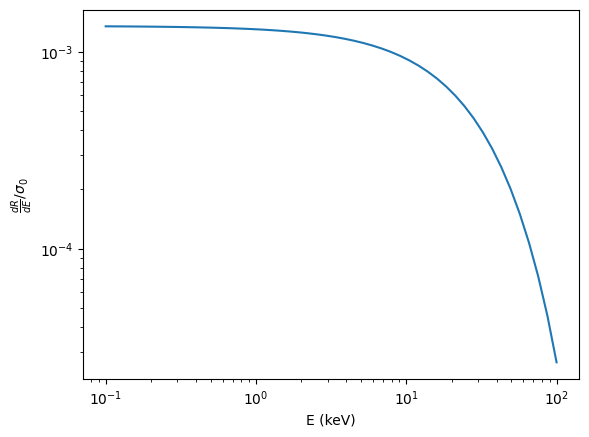

In [4]:
# Parameters
from scipy.constants import *

# Natural units
GeV = 1.0

vesc=544e3 / c
v0=220e3 / c
m_n = 76 * 0.9315   # GeV
m = 100             # GeV
rho = 0.3           # GeV / cm^3


eta = make_eta(speed_f(v0, vesc), vesc)

E_keV = np.logspace(-1, 2)  # 0.1 keV to 100 keV
E = E_keV * 1e-6  # GeV

plt.plot(E_keV, np.abs(dRdE(m, m_n, E, 1, rho, eta)))
plt.xscale('log')
plt.yscale('log')
plt.xlabel("E (keV)")
plt.ylabel(r"$\frac{dR}{dE} / \sigma_0$")
plt.show()

In [5]:
def dRdE_debug(m, m_n, E, sigma, rho, eta):
    mu = m * m_n / (m + m_n)
    prefactor = rho * sigma / (m * 2 * mu**2)
    E = np.asarray(E)

    v_min = np.sqrt(m_n * E / (2 * mu**2))
    print(f"v_min = {v_min}")
    print(f"prefactor = {prefactor}")
    return prefactor * eta(v_min)

print(v0, vesc)
# print(v_min(E_keV=1))   # pick a test energy
# print(eta(v_min(1e-6))) # check magnitude scale

0.0007338410094359345 0.0018145886778779471
